# Labwork 3 - Logistic Regression

In [28]:
def read_csv(file_name):
    with open(file_name, 'r') as csv:
        data = []
        next(csv)   # Skip header
        for line in csv:
            row = line.strip().split(',')
            experience = float(row[0])
            salary = float(row[1])
            loan = int(row[2])
            data.append((experience, salary, loan))

    for row in data:
        print(row)
        
    return data

data = read_csv('loan2.csv')

(3.0, 4.0, 1)
(2.5, 4.0, 1)
(1.0, 4.0, 0)
(2.5, 5.0, 1)
(2.0, 5.0, 1)
(1.5, 5.0, 0)
(0.5, 5.0, 0)
(1.75, 6.0, 1)
(0.25, 6.0, 0)
(1.0, 7.0, 1)
(0.25, 7.0, 0)
(0.2, 7.0, 0)
(0.15, 7.0, 0)
(2.0, 8.0, 1)
(1.0, 8.0, 0)
(0.15, 8.0, 0)
(0.1, 8.0, 0)
(0.5, 9.0, 1)
(1.0, 10.0, 1)


In [ ]:
import math

def f(x1, x2, w0, w1, w2):
    return w1*x1 + w2*x2 + w0

def sigmoid_function(z):
    return 1 / (1 + math.exp(-z))

# Binary cross entropy loss
def loss_function(data, w0, w1, w2):
    n = len(data)
    loss = 0
    for x1, x2, y in data:
        y_pred = sigmoid_function(f(x1, x2, w0, w1, w2))
        loss += -(y * math.log(y_pred) + (1 - y) * math.log(1 - y_pred))
    return loss / n



# Partial derivatives
def d_w0(data, w0, w1, w2):
    n = len(data)
    gradient = 0
    for x1, x2, y in data:
        y_pred = sigmoid_function(f(x1, x2, w0, w1, w2))
        gradient += y_pred - y
    return gradient / n

def d_w1(data, w0, w1, w2):
    n = len(data)
    gradient = 0
    for x1, x2, y in data:
        y_pred = sigmoid_function(f(x1, x2, w0, w1, w2))
        gradient += (y_pred - y) * x1
    return gradient / n

def d_w2(data, w0, w1, w2):
    n = len(data)
    gradient = 0
    for x1, x2, y in data:
        y_pred = sigmoid_function(f(x1, x2, w0, w1, w2))
        gradient += (y_pred - y) * x2
    return gradient / n


def gradient_descent(data, w0, w1, w2, learning_rate, threshold):
    i = 0
    while True:
        i += 1
        old_loss = loss_function(data, w0, w1, w2)
        w0 = w0 - learning_rate * d_w0(data, w0, w1, w2)
        w1 = w1 - learning_rate * d_w1(data, w0, w1, w2)
        w2 = w2 - learning_rate * d_w2(data, w0, w1, w2)
        new_loss = loss_function(data, w0, w1, w2)
        print(f"Iteration {i}: w1 = {w1:.4f}, w2 = {w2:.4f}, w0 = {w0:.4f}, loss = {new_loss:.4f}")
        if abs(old_loss - new_loss) <= threshold:
            break
    
    return w0, w1, w2

w0, w1, w2 = gradient_descent(data, w0=0, w1=1, w2=2, learning_rate=0.05, threshold=0.000001)

Iteration 1: w1 = 0.9866, w2 = 1.8290, w0 = -0.0263, loss = 6.5079
Iteration 2: w1 = 0.9732, w2 = 1.6579, w0 = -0.0526, loss = 5.9053
Iteration 3: w1 = 0.9597, w2 = 1.4869, w0 = -0.0789, loss = 5.3028
Iteration 4: w1 = 0.9463, w2 = 1.3158, w0 = -0.1053, loss = 4.7005
Iteration 5: w1 = 0.9329, w2 = 1.1449, w0 = -0.1316, loss = 4.0985
Iteration 6: w1 = 0.9195, w2 = 0.9740, w0 = -0.1578, loss = 3.4975
Iteration 7: w1 = 0.9062, w2 = 0.8034, w0 = -0.1841, loss = 2.8990
Iteration 8: w1 = 0.8930, w2 = 0.6335, w0 = -0.2102, loss = 2.3072
Iteration 9: w1 = 0.8801, w2 = 0.4656, w0 = -0.2359, loss = 1.7345
Iteration 10: w1 = 0.8679, w2 = 0.3034, w0 = -0.2608, loss = 1.2138
Iteration 11: w1 = 0.8574, w2 = 0.1570, w0 = -0.2833, loss = 0.8148
Iteration 12: w1 = 0.8504, w2 = 0.0445, w0 = -0.3009, loss = 0.6015
Iteration 13: w1 = 0.8481, w2 = -0.0228, w0 = -0.3121, loss = 0.5301
Iteration 14: w1 = 0.8497, w2 = -0.0568, w0 = -0.3185, loss = 0.5120
Iteration 15: w1 = 0.8534, w2 = -0.0735, w0 = -0.3225, 

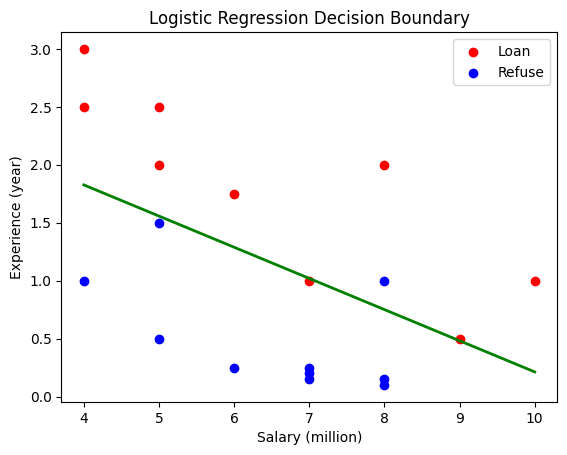

In [27]:
import matplotlib.pyplot as plt

# Data
x1_vals = [x1 for x1, x2, y in data]    # Experience
x2_vals = [x2 for x1, x2, y in data]    # Salary
y_vals  = [y for x1, x2, y in data]     # Loan

# Separate classes
x1_yes = [x1 for x1, x2, y in data if y == 1]
x2_yes = [x2 for x1, x2, y in data if y == 1]
x1_no = [x1 for x1, x2, y in data if y == 0]
x2_no = [x2 for x1, x2, y in data if y == 0]

plt.figure()

# Scatter plot
plt.scatter(x2_yes, x1_yes, color='red', label='Loan')   # Salary vs Experience
plt.scatter(x2_no, x1_no, color='blue', label='Refuse')

# Decision boundary line
x2_line = [i for i in range(4, 11)]     # Salary range
x1_line = []
for x2 in x2_line:
    x1 = -(w2 * x2 + w0) / w1
    x1_line.append(x1)

plt.plot(x2_line, x1_line, color="green", linewidth=2)
plt.xlabel("Salary (million)")
plt.ylabel("Experience (year)")
plt.title("Logistic Regression Decision Boundary")
plt.legend()
plt.show()